# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [11]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# PASO 1 Obtener el HTML de la web 
# Url de la  pagina a descargar en este caso la pagina de worldometers con los datos del coronavirus
resource_url = "https://www.worldometers.info/coronavirus/"
# Hacemos la peticion a la pagina http get a la url 
response = requests.get(resource_url)
# Imprimimos el codigo de estado de la respuesta para verificar que se ha descargado correctamente
print("Codigo de estado:", response.status_code)

if response.status_code != 200:
    raise Exception("No se pudo descargar la página")

Codigo de estado: 200


In [13]:
# PASO 2 Parsear el HTML con BeautifulSoup
# Creamos un objeto BeautifulSoup a partir del HTML descargado
soup = BeautifulSoup(response.text, "html.parser")

# luego con find buscamos la tabla que contiene los datos del coronavirus, esta tabla tiene un id "main_table_countries_today" lo hemos encontrado inspeccionando el codigo html de la pagina con las herramientas de desarrollo del navegador 
tabla = soup.find("table", id="main_table_countries_today")

print(tabla) 

<table class="table table-bordered table-hover main_table_countries" id="main_table_countries_today" style="width:100%;margin-top: 0px !important;display:none;">
<thead>
<tr>
<th width="1%">#</th>
<th width="100">Country,<br>Other</br></th>
<th width="20">Total<br>Cases</br></th>
<th width="30">New<br>Cases</br></th>
<th width="30">Total<br>Deaths</br></th>
<th width="30">New<br>Deaths</br></th>
<th width="30">Total<br>Recovered</br></th>
<th width="30">New<br>Recovered</br></th>
<th width="30">Active<br/>Cases</th>
<th width="30">Serious,<br/>Critical</th>
<th width="30">Tot Cases/<br/>1M pop</th>
<th width="30">Deaths/<br/>1M pop</th>
<th width="30">Total<br/>Tests</th>
<th width="30">Tests/<br/>
<nobr>1M pop</nobr>
</th>
<th width="30">Population</th>
<th style="display:none" width="30">Continent</th>
<th width="30">1 Case<br/>every X ppl</th><th width="30">1 Death<br/>every X ppl</th><th width="30">1 Test<br/>every X ppl</th>
<th width="30">New Cases/1M pop</th>
<th width="30">New 

In [ ]:
# Creamos listas vacías para guardar los datos
paises = []
total_casos = []
total_muertes = []
total_recuperados = []

# Recorremos todas las filas de la tabla (tr = filas)
#find_all("tr") devuelve una lista de todas las filas de la tabla
for fila in tabla.find_all("tr")[1:]:  # [1:] para saltar el encabezado
    
    # Obtenemos todas las celdas de la fila (td = columnas)
    celdas = fila.find_all("td")
    
    # Comprobamos que la fila tenga datos válidos
    if len(celdas) > 4:
        
        # Guardamos los datos en cada lista
        paises.append(celdas[1].get_text(strip=True))  # nombre del país
        
        # Quitamos comas para poder convertir luego a número
        # sttip=True para eliminar espacios en blanco al inicio y al final
        #replace(",", "") para eliminar las comas de los números grandes
        total_casos.append(celdas[2].get_text(strip=True).replace(",", ""))
        total_muertes.append(celdas[3].get_text(strip=True).replace(",", ""))
        total_recuperados.append(celdas[4].get_text(strip=True).replace(",", ""))

In [ ]:
import pandas as pd

# Creamos una tabla (DataFrame) con los datos
df = pd.DataFrame({
    "Pais": paises,
    #pd.to_numeric para convertir las cadenas de texto a números, 
    # 
    # errors="coerce" para convertir los valores no numéricos a NaN
    "Total_Casos": pd.to_numeric(total_casos, errors="coerce"),
    "Total_Muertes": pd.to_numeric(total_muertes, errors="coerce"),
    "Total_Recuperados": pd.to_numeric(total_recuperados, errors="coerce")
})

# Mostramos las primeras filas
print(df.head())

            Pais  Total_Casos  Total_Muertes  Total_Recuperados
0  North America    131889132            NaN          1695941.0
1           Asia    221500265            NaN          1553662.0
2         Europe    253406198            NaN          2101824.0
3  South America     70200879            NaN          1367332.0
4        Oceania     14895771            NaN            33015.0


In [ ]:
# Guardamos los datos en una base de datos SQLite
conn = sqlite3.connect("covid_data.db")
# to_sql para guardar el DataFrame en una tabla de la base de datos, 
# si la tabla ya existe se reemplaza, y no se guarda el índice del DataFrame como una columna
df.to_sql("covid_paises", conn, if_exists="replace", index=False)
conn.close()
print("Datos guardados correctamente en SQLite")

Datos guardados correctamente en SQLite


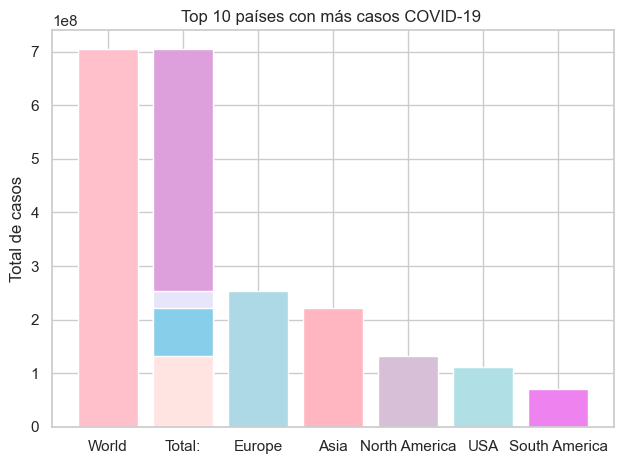

In [26]:
import matplotlib.pyplot as plt
# Top 10 países con más casos
#nlargest(10, "Total_Casos") para obtener las 10 filas con los valores más altos en la columna "Total_Casos"
top10_casos = df.nlargest(10, "Total_Casos")
# Colores pastel simples
colores_pastel = ["pink", "plum", "lightblue", "lavender", "lightpink",
                   "skyblue", "thistle", "mistyrose", "powderblue", "violet"]
# Gráfico de barras
plt.bar(top10_casos["Pais"], top10_casos["Total_Casos"], color=colores_pastel)
plt.title("Top 10 países con más casos COVID-19 ")
plt.ylabel("Total de casos")
plt.tight_layout()
plt.show()